In [1]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

KeyboardInterrupt: 

In [ ]:
WORKLOAD = "bc-kron.sg"

In [ ]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""
    
    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"(\d+)MiB", path.name)
    return int(match.group(1)) if match else None

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

roots = {
    "arms": Path(f"/users/zimooo2/tiering_solutions/times/arms/{WORKLOAD}"),
    "model": Path(f"/users/zimooo2/tiering_solutions/times/model/{WORKLOAD}"),
}

records: list[dict] = []
for label, root in roots.items():
    for path in sorted(root.glob("*.time")):
        if "train" in path.name:
            continue
        metrics = parse_time_file(path)
        try:
            log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
        except FileNotFoundError:
            log_metrics = {}
        records.append({
            "policy": label,
            "file": path.name,
            "MiB": extract_mib(path),
            **metrics,
            **log_metrics,
        })

df = pd.DataFrame(records)
df

,policy,file,MiB,real,user,sys
0,arms,1000MiB_run1.time,1000,680.307,0.400,0.954
1,arms,1500MiB_run1.time,1500,578.294,0.392,0.900
2,arms,2000MiB_run1.time,2000,548.054,0.423,0.900
3,arms,3000MiB_run1.time,3000,449.999,0.251,0.645
4,arms,4000MiB_run1.time,4000,427.564,0.249,0.604
5,arms,5000MiB_run1.time,5000,414.658,0.248,0.640
6,model,1000MiB_run1.time,1000,673.239,0.680,1.589
7,model,1500MiB_run1.time,1500,567.966,0.611,1.402
8,model,2000MiB_run1.time,2000,540.744,0.599,1.394
9,model,3000MiB_run1.time,3000,438.943,0.348,0.896


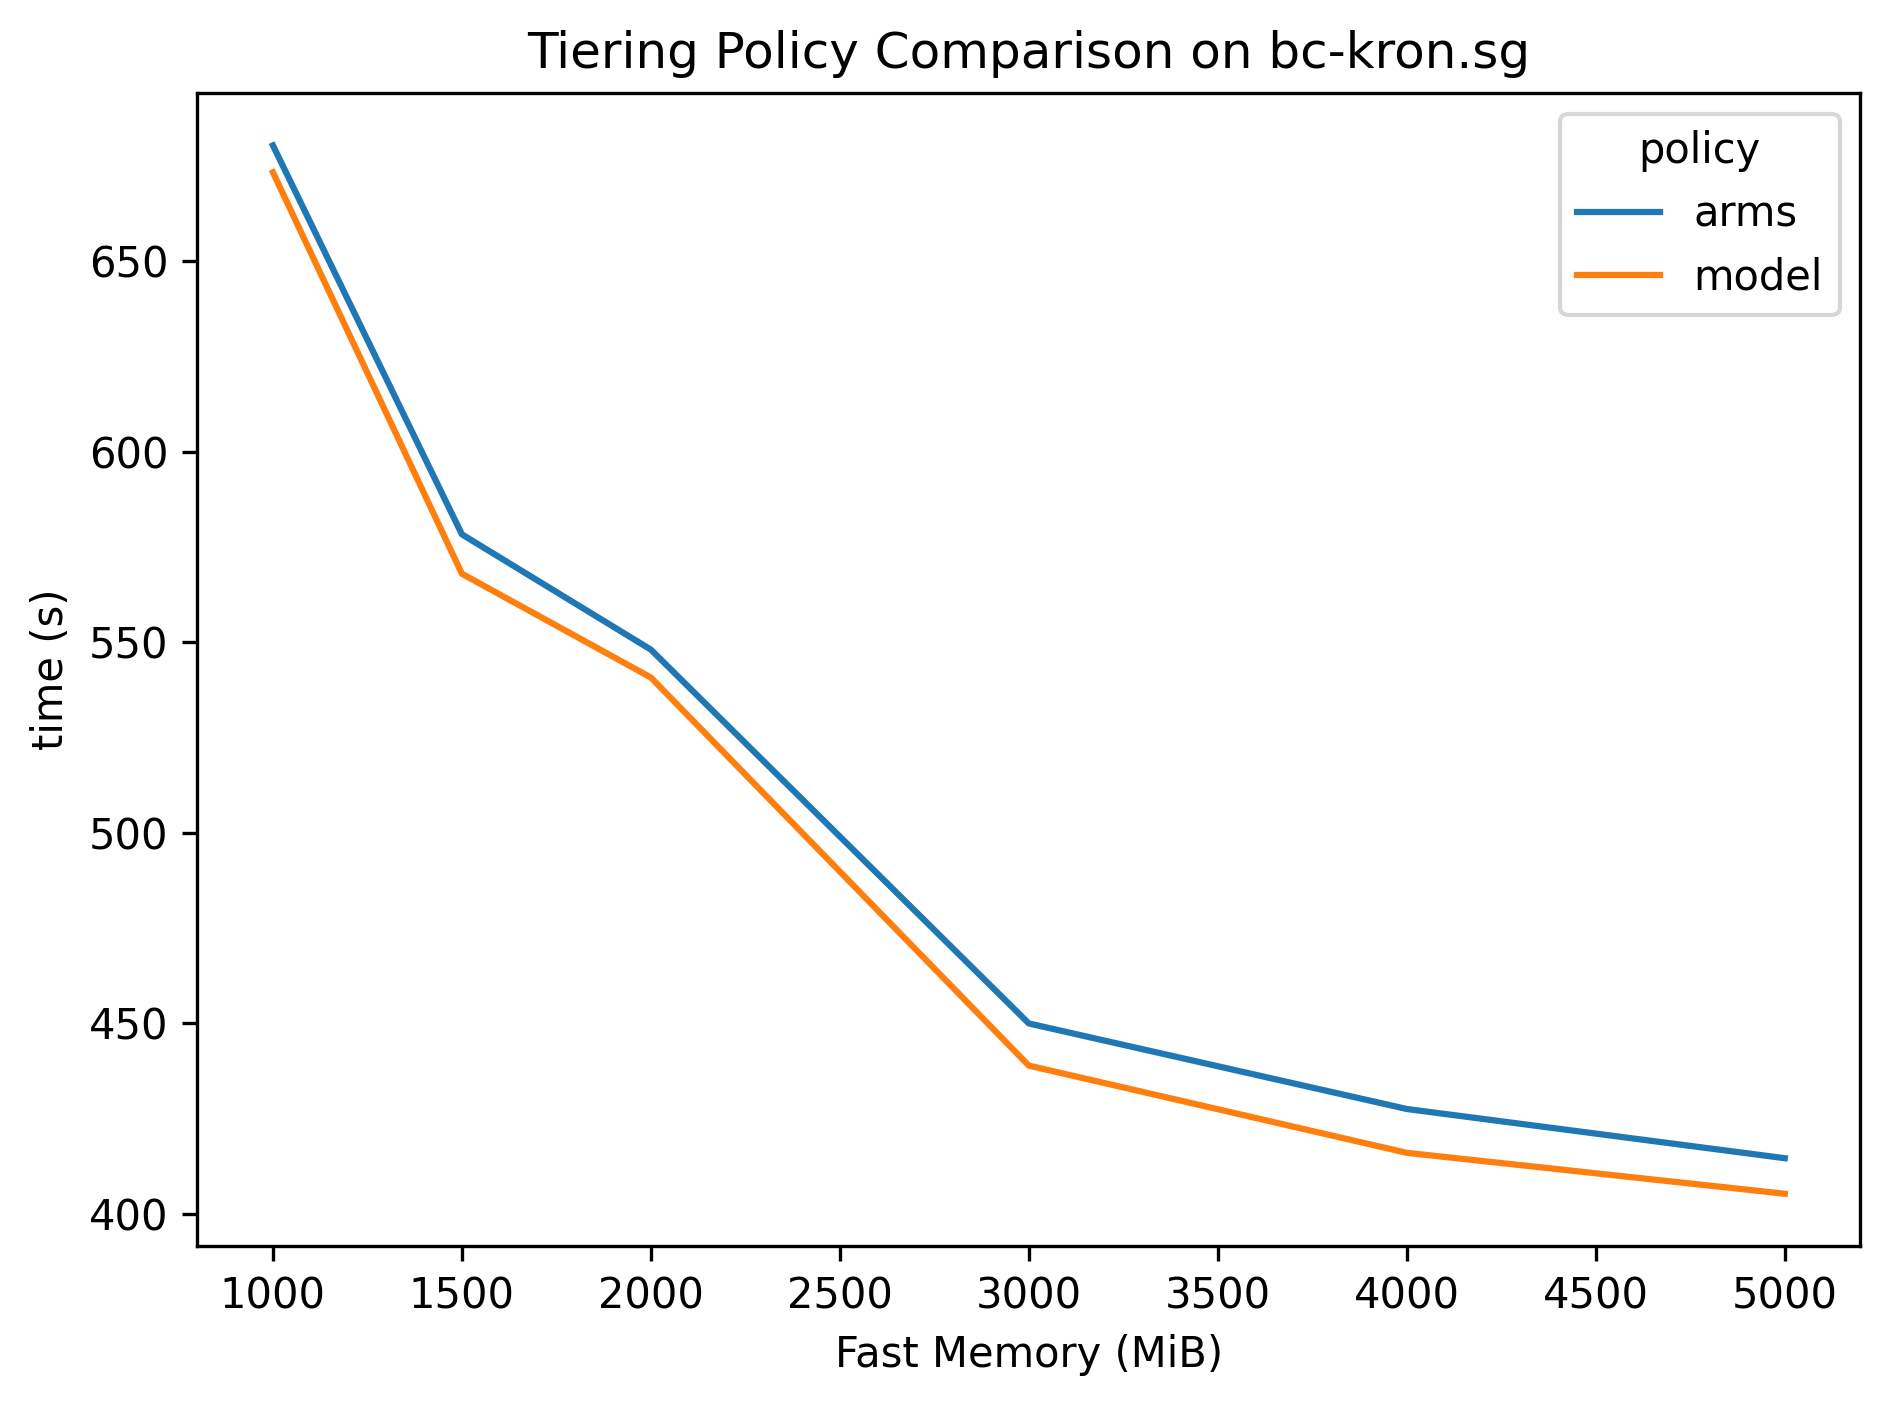

In [ ]:
import matplotlib.pyplot as plt

graph_dir = Path("graphs")
graph_dir.mkdir(parents=True, exist_ok=True)

ax = sns.lineplot(data=df, x="MiB", y="real", hue="policy")
ax.set(
    ylabel="time (s)",
    xlabel="Fast Memory (MiB)",
    title=f"Tiering Policy Comparison on {WORKLOAD}",
)

plt.tight_layout()
plt.savefig(graph_dir / f"{WORKLOAD}.png")
plt.gcf().set_dpi(300)

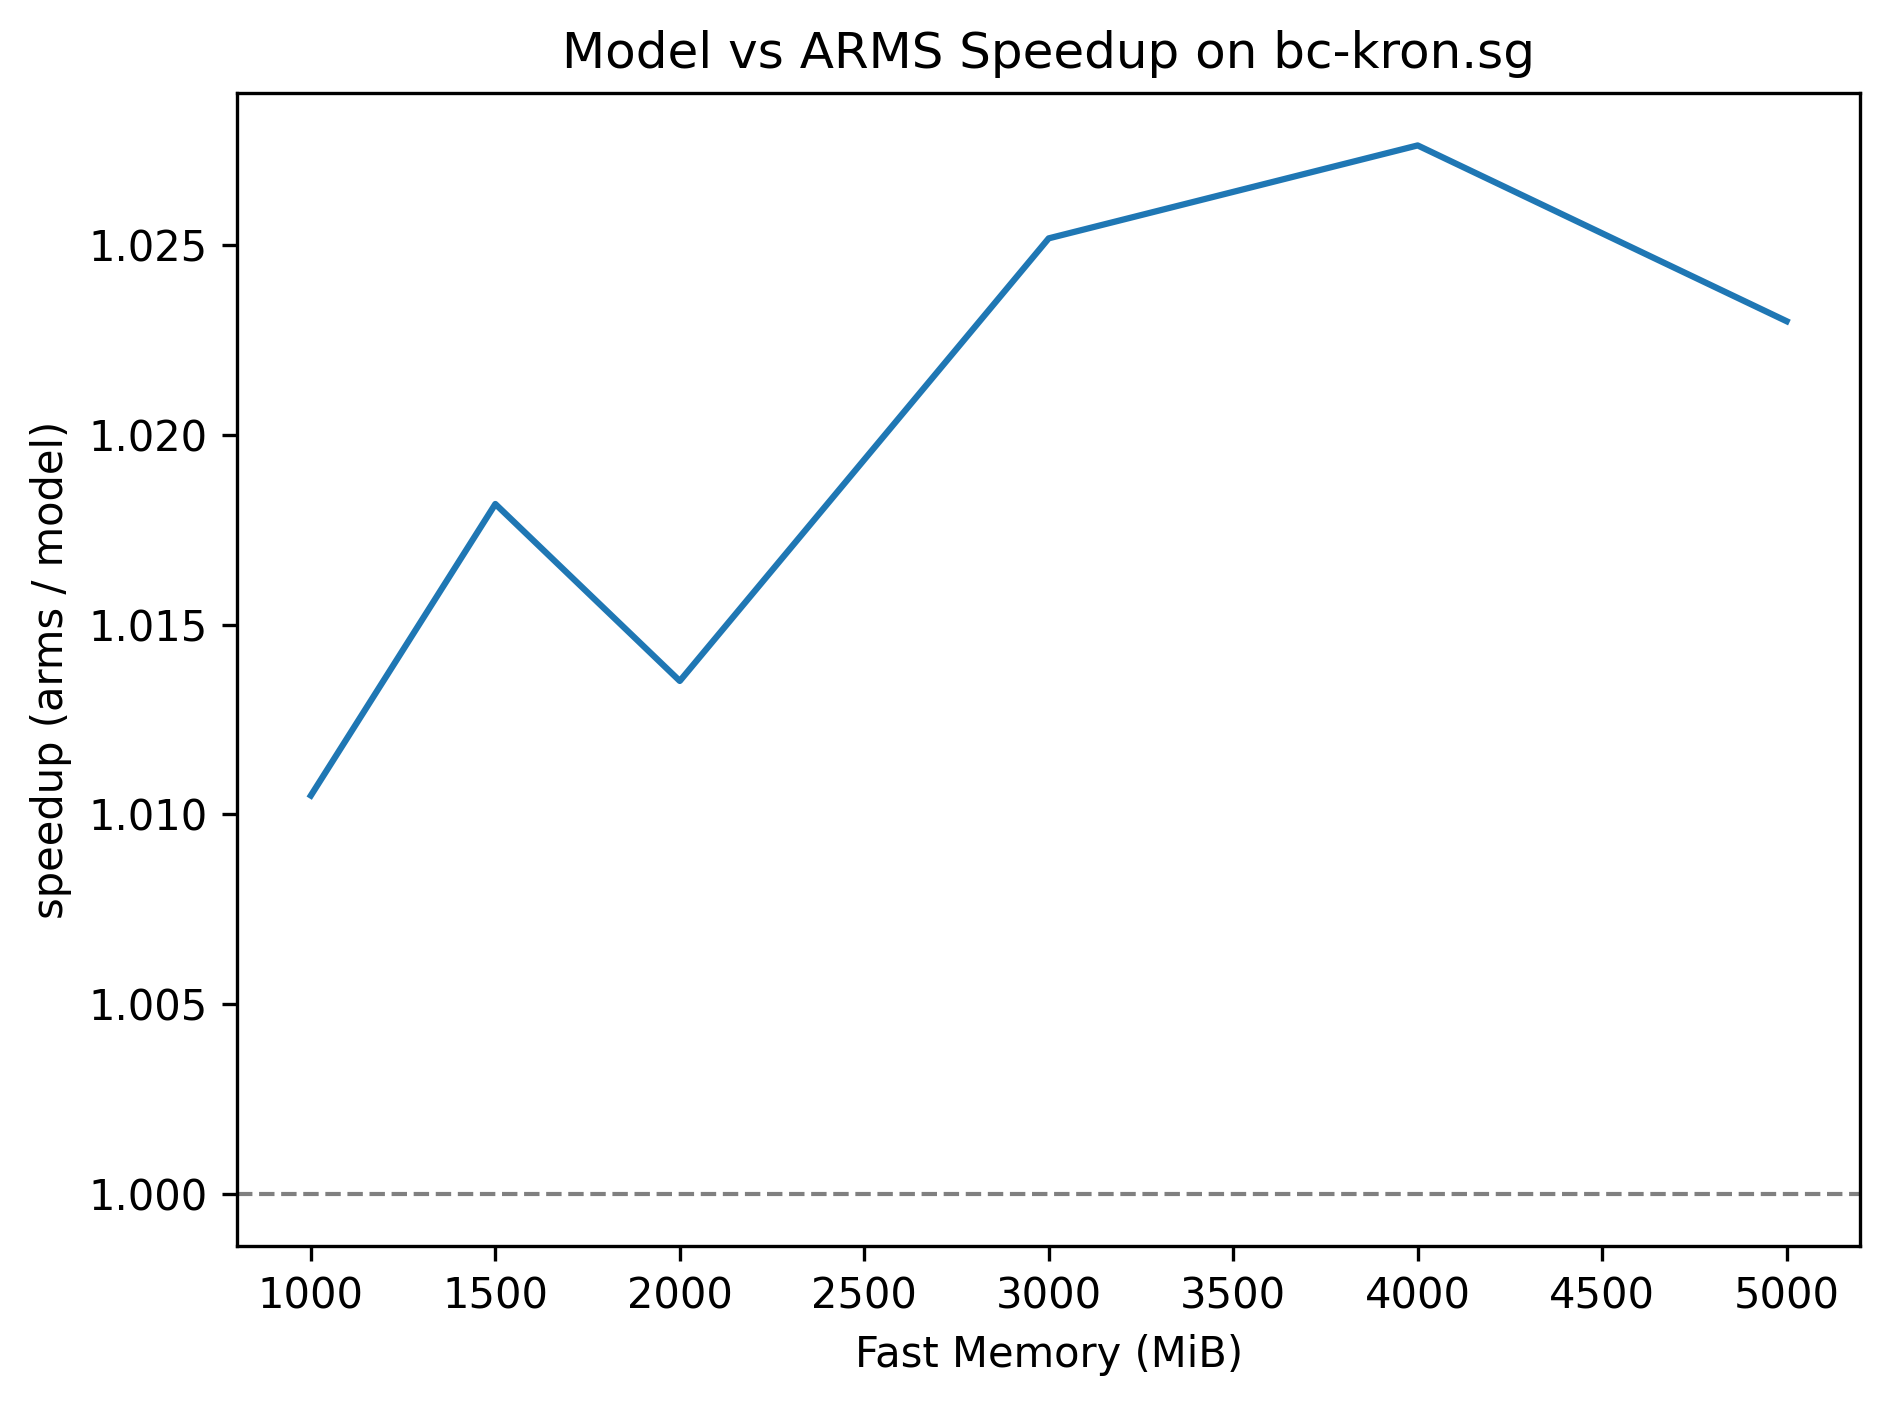

In [ ]:
df_speedup = (
    df.pivot(index="MiB", columns="policy", values="real")
    .dropna(subset=["arms", "model"])
    .reset_index()
)

# Speedup of model relative to arms (>1.0 means model is faster)
df_speedup["speedup_model_vs_arms"] = df_speedup["arms"] / df_speedup["model"]

ax = sns.lineplot(data=df_speedup, x="MiB", y="speedup_model_vs_arms")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set(
    ylabel="speedup (arms / model)",
    xlabel="Fast Memory (MiB)",
    title=f"Model vs ARMS Speedup on {WORKLOAD}",
)
plt.tight_layout()
plt.savefig(graph_dir / f"{WORKLOAD}_speedup.png")
plt.gcf().set_dpi(300)
